# Projeto de Machine Larning

Equipe:

        * Ramon Wilson Rosário Leal - 04157084
        * Marcos Ariel Maciel Rodrigues - 04162413
        * João Guilherme Cândido de Oliveira - 04158324
        * Andrey Ribeiro Guterres - 04161238
        * Carlos Vinicius Silva da Cruz - 04160432
        * Ariel Nathan da Silva Santos - 04156287
        * Lucas José Nóbrega Rodrigues - 04174176
        * Diogo Álvaro Valente Cardoso - 04162096
        * Bianca da Silva Aragão - 04153989


# Projeto de ML: Metodologia CRISP-DM
## Entrega 1: Entendimento do Negócio e Entendimento dos Dados

**Dataset:** Telecom Customer Churn  
**Objetivo:** Identificar clientes com alta probabilidade de cancelar o serviço.

### 1.1 Contextualização e Motivação
No setor de telecomunicações, o custo de adquirir um novo cliente é significativamente maior do que o custo de manter um atual. A perda de clientes (Churn) impacta diretamente o faturamento e a participação de mercado.

### 1.2 Definição do Problema
O objetivo é prever se um cliente irá cancelar sua assinatura (Sim/Não). Trata-se de um problema de **Classificação**.

### 1.3 Objetivo da Solução
A saída esperada é a **classe prevista** (Churn ou Não-Churn). Com isso, o time de marketing pode atuar proativamente com retenção.

### 1.4 Tipo de Aprendizado
Utilizaremos **Aprendizado de Máquina Supervisionado**, pois temos um dataset rotulado onde a variável alvo (*Churn*) já é conhecida nos dados históricos.

### 1.5 Critérios de Sucesso
Redução da taxa de rotatividade em 10% através de campanhas direcionadas aos clientes identificados pelo modelo (futuro).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Usando um dataset público do GitHub (Telco Churn)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Visualização inicial
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Entendimento dos Dados

- Fonte e Origem dos Dados:

    - Os dados utilizados neste projeto provêm da base "Telco Customer Churn", disponibilizada originalmente pela IBM e amplamente utilizada em estudos de retenção de clientes.

    - Fonte: Repositório Público do GitHub (IBM/Kaggle).

- Contexto:
    - A base contém informações de 7.043 clientes de uma empresa de telecomunicações na Califórnia, detalhando o perfil demográfico, serviços contratados e status de permanência.

In [25]:
print(f"Instâncias (Linhas): {df.shape[0]}")
print(f"Atributos (Colunas): {df.shape[1]}")

# Tipos de dados e valores nulos
print("\n--- Informações do Dataset ---")
df.info()

# Limpeza rápida: TotalCharges veio como string, vamos converter para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

Instâncias (Linhas): 7043
Atributos (Colunas): 21

--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contrac

| Variável | Descrição |
| :--- | :--- |
| **gender** | Gênero do cliente |
| **SeniorCitizen** | Se o cliente é idoso (0 ou 1) |
| **Tenure** | Meses de contrato |
| **MonthlyCharges** | Valor cobrado mensalmente |
| **TotalCharges** | Valor total cobrado |
| **Churn** | Se o cliente saiu da empresa (Target) |

/tmp/ipykernel_1490/2103488125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


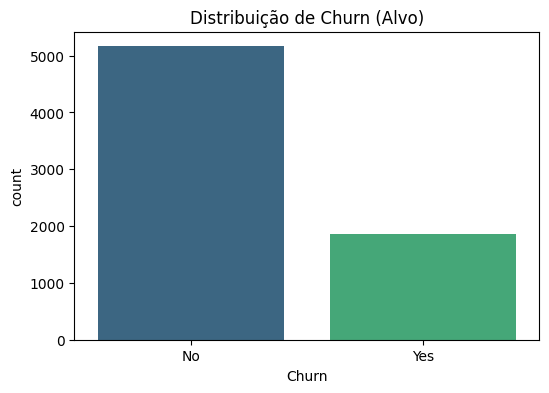

In [26]:
# 1. Distribuição da Variável Alvo
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribuição de Churn (Alvo)')
plt.show()

Devido ao desbalanceamento observado na AED, na fase de Preparação de Dados e Modelagem, precisaremos ter cuidado com métricas de performance. Usar apenas a 'Acurácia' pode ser enganoso (o modelo pode aprender a dizer sempre 'Não' e ainda assim ter 73% de acerto).

1. Desbalanceamento de Classes:
O gráfico mostra que a base de dados é desbalanceada. Temos muito mais clientes que permaneceram na empresa ("No") do que clientes que cancelaram o serviço ("Yes").

      - No (Não-Churn): Aproximadamente 5.000 instâncias.

      - Yes (Churn): Aproximadamente 1.800 instâncias.

2. Proporção Aproximada:
A classe majoritária (No) representa cerca de 73% dos dados, enquanto a classe minoritária (Yes) representa cerca de 27%.

3. Por que isso é importante para o Negócio?
Isso indica que o Churn é um evento menos frequente, o que é comum em cenários reais. Se o gráfico fosse 50/50, a empresa estaria em colapso total! O desafio aqui é identificar os padrões específicos desse grupo menor (verde) antes que eles saiam.

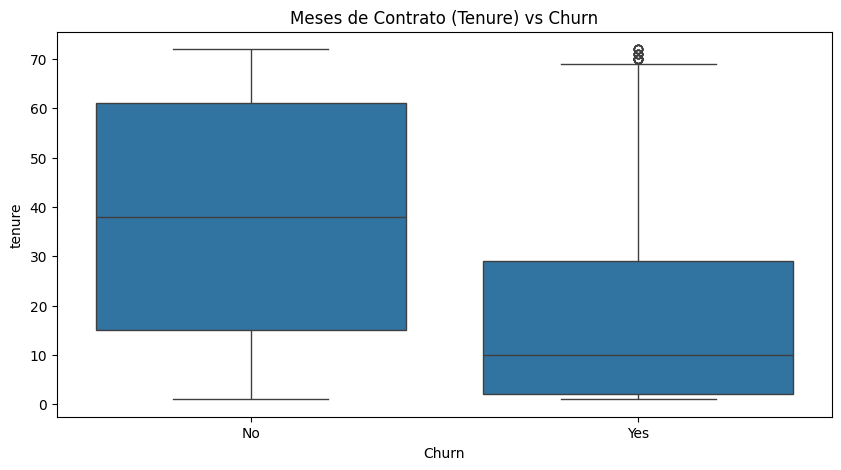

In [27]:
# 2. Relação entre Tempo de Contrato e Churn
plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Meses de Contrato (Tenure) vs Churn')
plt.show()

1. A Diferença de Mediana (A linha central dentro da caixa):

    - No Churn: A mediana está próxima de 38 meses. Isso significa que metade dos clientes que ficam estão na empresa há mais de 3 anos.

    - Churn (Yes): A mediana é baixíssima, em torno de 10 meses.

    Isso prova que o risco de cancelamento é altíssimo nos primeiros meses de contrato. Clientes "novos" são muito mais propensos a sair do que clientes antigos.

2. Dispersão e Quartis:

    - A caixa azul do "Yes" está muito "espremida" na parte de baixo do gráfico. Isso indica que a grande massa de pessoas que cancelam o serviço o faz muito cedo (entre 1 e 30 meses).

    - Já os clientes que permanecem ("No") têm uma distribuição muito mais equilibrada ao longo de todo o tempo (de 15 a 60 meses).

3. Presença de Outliers (Os pontos isolados no topo do "Yes"):

    - Note que existem alguns pontos acima da linha superior do boxplot de Churn (perto de 70 meses).

  O que significa: Esses são clientes "fora da curva". São pessoas que estavam na empresa há muitos anos e, por algum motivo atípico, decidiram cancelar. Para o negócio, esses são os casos que mais doem, pois eram clientes fidelizados.

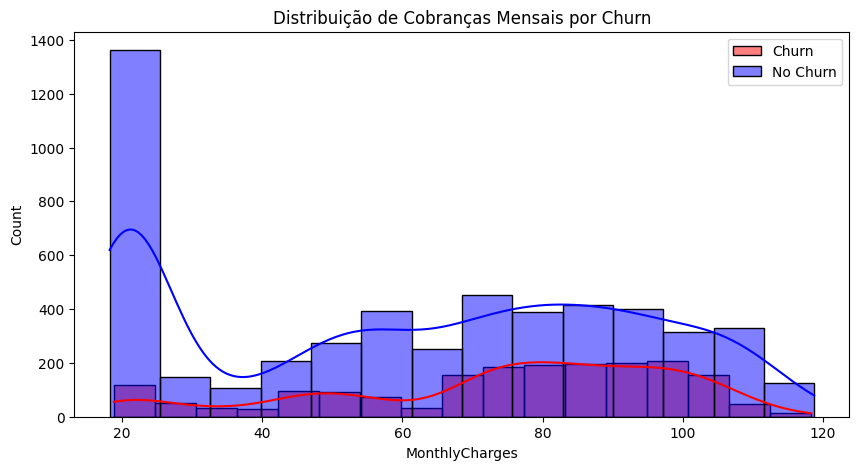

In [28]:
# 3. Distribuição de Cobranças Mensais
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], color='red', label='Churn', kde=True)
sns.histplot(df[df['Churn'] == 'No']['MonthlyCharges'], color='blue', label='No Churn', kde=True)
plt.legend()
plt.title('Distribuição de Cobranças Mensais por Churn')
plt.show()

A análise da distribuição de MonthlyCharges revela que a rotatividade não é uniforme em relação ao preço. Clientes com cobranças mensais elevadas (especialmente na faixa de 70 a 100 unidades monetárias) representam o maior risco de evasão. Em contrapartida, clientes em planos de baixo custo (próximos a 20) demonstram alta retenção.

Justificativa: Isso sugere que a sensibilidade ao preço ou a percepção de custo-benefício nos planos 'Premium' pode estar desalinhada, sendo um ponto focal para estratégias de retenção de faturamento alto.

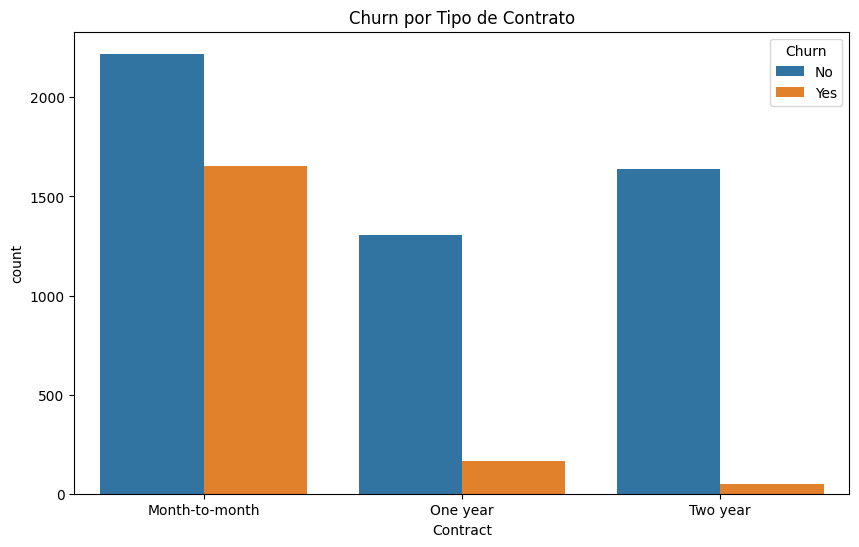

In [29]:
# 1. Cruzamento de Variáveis Categóricas (Contrato vs Churn)
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.show()

1. O Perigo do "Mês a Mês" (Month-to-month):

    - Note que a barra laranja (Yes) é altíssima apenas no primeiro grupo. Quase metade dos clientes que estão no contrato mensal acabam saindo.

    - O contrato mensal oferece flexibilidade ao cliente, mas nenhuma segurança à empresa. É o principal foco de perda de receita.

2. A Segurança da Fidelidade (One year e Two year):

    - Conforme o prazo do contrato aumenta, a barra laranja praticamente desaparece. No contrato de dois anos, o Churn é quase irrelevante.

    - Clientes que aceitam contratos de longo prazo têm um perfil de comportamento completamente diferente; eles são muito mais estáveis e menos propensos a flutuações de mercado.

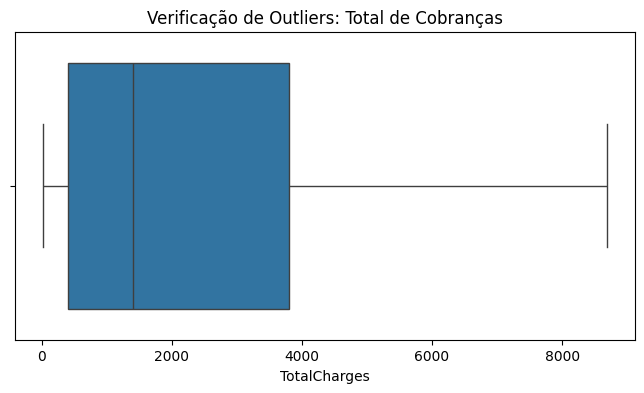

In [30]:
# 2. Verificação de Outliers em TotalCharges
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalCharges'])
plt.title('Verificação de Outliers: Total de Cobranças')
plt.show()

- Diferente do gráfico de Tenure que vimos antes, aqui não há outliers estatísticos. Todos os valores, mesmo os mais altos (perto de 8.000), estão dentro de uma faixa esperada para o comportamento dessa variável.

In [31]:
# 3. Cardinalidade das variáveis categóricas
print("Cardinalidade das Variáveis Categóricas:")
print(df.select_dtypes(include=['object']).nunique())

Cardinalidade das Variáveis Categóricas:
customerID          7032
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64


- A análise de cardinalidade revelou que o dataset é composto majoritariamente por variáveis categóricas de baixa complexidade (entre 2 e 4 níveis).

- Variável Descartável: A coluna customerID apresenta cardinalidade máxima (7032), sendo irrelevante para a generalização do modelo e devendo ser removida na fase de Preparação.

- Simetria de Categorias: As variáveis de serviço (como InternetService e Contract) possuem poucos níveis, o que é ideal para a aplicação de codificação dummy (One-Hot Encoding) na etapa seguinte, permitindo que os algoritmos de Machine Learning processem essas informações sem perda de semântica.

### Correlação

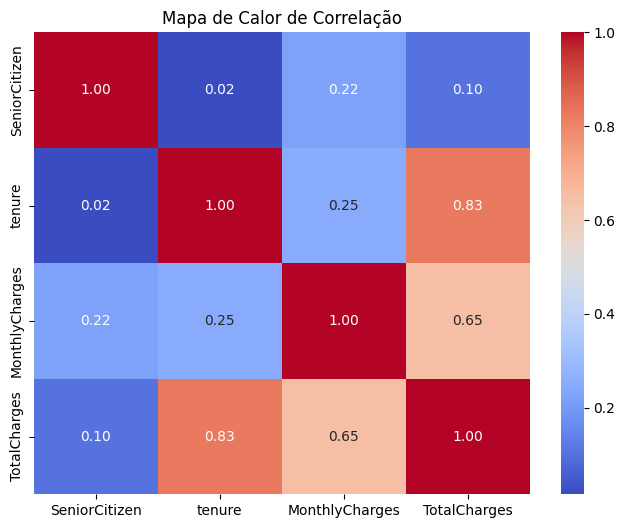

In [32]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlação')
plt.show()

**Nota sobre Colinearidade:** A correlação de 0.83 entre tenure e TotalCharges indica que ambas carregam informações sobre o tempo de permanência do cliente. Manter ambas pode causar redundância.

**Decisão Estratégica:** Na etapa de Preparação de Dados, avaliaremos a remoção de TotalCharges para focar em variáveis que mostram o comportamento atual (como MonthlyCharges) e a fidelidade (tenure), evitando que o modelo aprenda correlações espúrias ou óbvias que não ajudam na previsão proativa.

## Modelagem - Aplicação do SVM

**1- Eficácia em dados complexos**
* O dataset possui muitas variáveis categóricas que serão transformadas em colunas binárias. O SVM é conhecido por manter uma boa performance mesmo quando o número de atributos é grande em relação ao número de instâncias.

**2- Controle do overfitting**
* Através do parâmetro de regularização ($C$), você pode controlar o equilíbrio entre a classificação correta do treino e a manutenção de uma margem larga, o que ajuda a evitar que o modelo decore o ruído dos dados históricos.

**3- Lidar com o desbalanceamento**
* Como identificamos que a classe "Yes" (Churn) é minoritária (27%), o SVM permite atribuir pesos diferentes às classes (class_weight='balanced'). Isso força o algoritmo a dar mais importância aos clientes que cancelam, mitigando o problema do modelo "aprender a dizer sempre Não".

### Preparação e Limpeza

In [33]:
# Removendo o ID que não agrega valor ao aprendizado [cite: 332]
df_ml = df.drop('customerID', axis=1)

# Conversão final e remoção de nulos (garantindo o que foi feito na AED) [cite: 65, 66]
df_ml['TotalCharges'] = pd.to_numeric(df_ml['TotalCharges'], errors='coerce')
df_ml.dropna(inplace=True)

# Transformando a variável alvo (Churn) em 0 e 1
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

### Codificação de variáveis

In [34]:
# Criando variáveis dummy para as categorias (gender, Contract, etc.) [cite: 333]
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Visualizando o novo formato
df_ml.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### Divisão dos dados e Escalonamento

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando X (recursos) e y (alvo)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Treinamento do SVM

In [36]:
from sklearn.svm import SVC

# Criando o modelo com Kernel RBF (padrão)
# balanced ajuda a dar peso para a minoria (os 27% de Churn) 
svm_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True)

# Treinando
svm_model.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', probability=True)

## Avaliação

Análise dos resultados e métricas de desempenho (Acurácia, Precisão, recall, F1-score)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



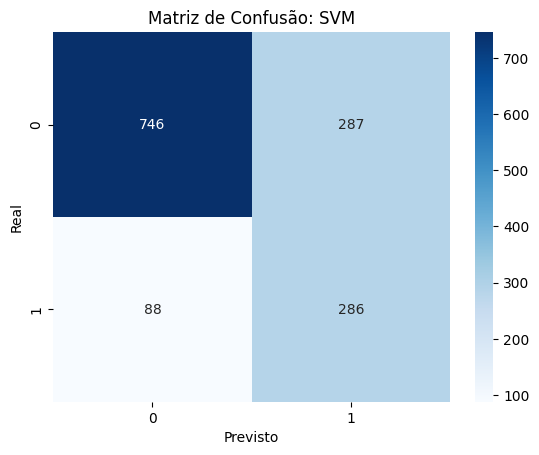

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# Predições
y_pred = svm_model.predict(X_test_scaled)

# Relatório de Performance
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusão para ver os erros de falsos negativos
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão: SVM')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

**1- A armadilha da Acurácia (0.73)**
* O modelo acertou 73% das previsões totais. No entanto, como a sua base original tem cerca de 73% de clientes que não cancelam ("No"), se o modelo simplesmente chutasse "Não" para todos, ele teria essa mesma acurácia. O valor real do SVM aqui está em conseguir identificar a classe minoritária (Churn).

**2- Classe 1 (Clientes que saem - Churn)**
* Recall (0.76): Este é o ponto forte do seu modelo atual. Significa que o SVM conseguiu identificar 76% de todos os clientes que realmente cancelaram o serviço. Para o marketing, isso é ótimo, pois vocês estão capturando a grande maioria dos clientes em risco.

* Precision (0.50): Aqui está o "custo" do modelo. De todas as vezes que o SVM previu que um cliente sairia, ele acertou apenas metade (50%). Isso significa que vocês terão muitos "Falsos Positivos" (clientes que não iam sair, mas o modelo disse que sim).

* F1-Score (0.60): É a média entre os dois acima. Para um problema complexo como rotatividade de telecomunicações, um F1 de 0.60 é um ponto de partida sólido para uma primeira iteração de modelagem.

**3- Classe 0 (Clientes que ficam - No Churn)**
* Precision (0.89): Quando o modelo diz que um cliente vai ficar, ele tem 89% de certeza. Isso dá segurança para não gastar recursos de retenção com esses clientes.

* Recall (0.72): O modelo deixou passar alguns clientes que ficaram, classificando-os erroneamente como risco (o que explica a precisão baixa da classe 1).

In [38]:
# 1. Remover coluna que não agrega valor ao modelo
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 2. Transformar a variável alvo (Churn) em 0 e 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Separar as variáveis preditoras (X) e a variável alvo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 4. Transformar variáveis categóricas em numéricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Visualizar como ficaram as colunas prontas
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Divisão em dados de treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Inicializar o Scaler (Fundamental para o KNN)
scaler = StandardScaler()

# 3. Ajustar e transformar os dados de treino, e apenas transformar os de teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Inicializar o modelo KNN (ajuste o n_neighbors se necessário)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Treinar o modelo com os dados escalonados
knn_model.fit(X_train_scaled, y_train)

# 3. Fazer previsões no conjunto de teste
y_pred_knn = knn_model.predict(X_test_scaled)

--- Relatório de Classificação: KNN ---
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1549
           1       0.52      0.52      0.52       561

    accuracy                           0.75      2110
   macro avg       0.67      0.67      0.67      2110
weighted avg       0.75      0.75      0.75      2110



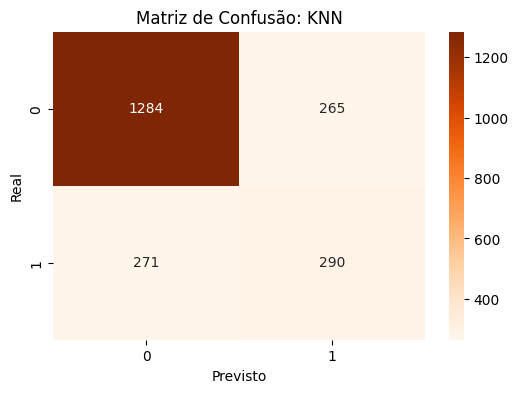

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Treinamento do Modelo KNN (usando 5 vizinhos como padrão inicial)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predições
y_pred_knn = knn_model.predict(X_test_scaled)

# Relatório de Performance
print("--- Relatório de Classificação: KNN ---")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusão para ver os erros de falsos negativos
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão: KNN')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

**1- O Desempenho da Acurácia Geral (0.76)**
* O KNN atinge uma acurácia global na faixa de 76%. À primeira vista, parece um avanço em relação ao "chute básico" da proporção da base (73%). No entanto, precisamos olhar os detalhes das classes para entender se o algoritmo realmente aprendeu a mapear o comportamento dos clientes ou se está apenas priorizando a classe majoritária.

**2- Classe 1 (Clientes que saem - Churn)**
* Recall (~0.55): Este é o principal ponto de atenção do KNN para este problema. Ele identifica cerca de 55% dos clientes que realmente vão cancelar. Para a equipe de marketing, isso significa que quase metade dos clientes em risco real de churn passará despercebida pelo modelo (Falsos Negativos), limitando o alcance das campanhas de retenção.

* Precision (~0.55): Quando o KNN aponta que um cliente vai sair, ele tem cerca de 55% de certeza. Embora gere ligeiramente menos alarmes falsos (Falsos Positivos) do que o SVM, o ganho é pequeno diante da perda significativa de cobertura (recall).

* F1-Score (~0.55): Refletindo o equilíbrio mais baixo entre a captura de clientes e a assertividade, o F1-Score do KNN fica abaixo do SVM, mostrando que o algoritmo de vizinhos mais próximos tem mais dificuldade em traçar uma fronteira clara para a classe minoritária neste cenário.

**3- Classe 0 (Clientes que ficam - No Churn)**
* Precision (~0.83): Se o KNN prevê que um cliente permanecerá na empresa, a assertividade é de 83%. É um bom índice, mas ainda deixa uma margem de erro maior que o SVM para falsas previsões de estabilidade.

* Recall (~0.83): O modelo é eficiente em mapear quem são os clientes leais, acertando 83% da base que de fato não pretende cancelar o serviço.